In [1]:
import io
import os
import pickle
import json
import h5py

import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from sklearn.decomposition import NMF, PCA

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm, SymLogNorm

In [2]:
from pyFAI.azimuthalIntegrator import AzimuthalIntegrator
from pyFAI.detectors import Detector

from ePDF.DAG.diffraction import integrate_single

In [3]:
# Read the DM4 file
# Open the datacube as a 4D numpy array

with h5py.File('data/TiO2_dataset.h5', 'r') as f:
    # Load the datacube into memory
    X = np.array(f['X4D'])
    Xr = np.array(f['coordinates/x_real'])
    Yr = np.array(f['coordinates/y_real'])
    Xq = np.array(f['coordinates/x_reciprocal'])
    Yq = np.array(f['coordinates/y_reciprocal'])
    meta = json.loads(f['metadata'][()])
    beamstop = np.array(f['coordinates/beamstop'])

x_real, y_real, x_reci, y_reci = X.shape

Xf = X.reshape(X.shape[0] * X.shape[1], X.shape[2] * X.shape[3])
Xf = Xf.clip(min=0, max=1e32)

print(x_real, y_real, x_reci, y_reci)

26 78 187 187


In [4]:
import time
from math import log, sqrt
from functools import partial

from sklearn.utils import check_random_state
from sklearn.decomposition._nmf import _initialize_nmf, _beta_divergence
from sklearn.decomposition._cdnmf_fast import _update_cdnmf_fast

from scipy import fftpack, linalg, sparse
from sklearn.utils import check_random_state, check_array
from sklearn.utils.extmath import safe_sparse_dot

def random_axis_sample(A, l, axis, random_state):
    return random_state.choice(A.shape[axis], size=l, replace=False)

def random_gaussian_map(A, l, axis, random_state):
    return random_state.standard_normal(size=(A.shape[axis], l)).astype(A.dtype)

def random_uniform_map(A, l, axis, random_state):
    return random_state.uniform(-1, 1, size=(A.shape[axis], l)).astype(A.dtype)

def sparse_random_map(A, l, axis, density, random_state):
    values = (-sqrt(1. / density), sqrt(1. / density))
    data_rvs = partial(random_state.choice, values)
    return sparse.random(A.shape[axis], l, density=density, data_rvs=data_rvs,
                         random_state=random_state, dtype=A.dtype)

def johnson_lindenstrauss(A, l, axis=1, random_state=None):
    random_state = check_random_state(random_state)
    A = np.asarray(A)
    Omega = random_gaussian_map(A, l, axis, random_state)
    if axis == 0:
        return Omega.T.dot(A)
    return A.dot(Omega)

def sparse_johnson_lindenstrauss(A, l, density=None, axis=1, random_state=None):
    random_state = check_random_state(random_state)
    A = np.asarray(A)
    if density is None:
        density = log(A.shape[0]) / A.shape[0]
    Omega = sparse_random_map(A, l, axis, density, random_state)
    if axis == 0:
        return safe_sparse_dot(Omega.T, A)
    return safe_sparse_dot(A, Omega)

def orthonormalize(A, overwrite_a=True, check_finite=False):
    Q, _ = linalg.qr(A, overwrite_a=overwrite_a, check_finite=check_finite,
                     mode='economic', pivoting=False)
    return Q

def perform_subspace_iterations(A, Q, n_iter=2, axis=1):
    if axis == 0:
        Q = Q.T
    Q = orthonormalize(Q)
    for _ in range(n_iter):
        if axis == 0:
            Z = orthonormalize(A.dot(Q))
            Q = orthonormalize(A.T.dot(Z))
        else:
            Z = orthonormalize(A.T.dot(Q))
            Q = orthonormalize(A.dot(Z))
    if axis == 0:
        return Q.T
    return Q

def conjugate_transpose(A):
    if A.dtype == np.complexfloating:
        return A.conj().T
    return A.T

def _compute_rqb(A, rank, oversample, n_subspace, sparse, random_state):
    if sparse:
        Q = sparse_johnson_lindenstrauss(A, rank + oversample,
                                         random_state=random_state)
    else:
        Q = johnson_lindenstrauss(A, rank + oversample, random_state=random_state)
    if n_subspace > 0:
        Q = perform_subspace_iterations(A, Q, n_iter=n_subspace, axis=1)
    else:
        Q = orthonormalize(Q)
    B = conjugate_transpose(Q).dot(A)
    return Q, B

def compute_rqb(A, rank, oversample=20, n_subspace=2, n_blocks=1, sparse=False,
                random_state=None):
    if n_blocks > 1:
        m, n = A.shape
        row_sets = np.array_split(range(m), n_blocks)
        Q_block = []
        K = []
        for rows in row_sets:
            Qtemp, Ktemp = _compute_rqb(np.asarray_chkfinite(A[rows, :]), 
                rank=rank, oversample=oversample, n_subspace=n_subspace, 
                sparse=sparse, random_state=random_state)
            Q_block.append(Qtemp)
            K.append(Ktemp)
        Q_small, B = _compute_rqb(
            np.concatenate(K, axis=0), rank=rank, oversample=oversample,
            n_subspace=n_subspace, sparse=sparse, random_state=random_state)
        Q_small = np.vsplit(Q_small, n_blocks)
        Q = [Q_block[i].dot(Q_small[i]) for i in range(n_blocks)]
        Q = np.concatenate(Q, axis=0)
    else:
        Q, B = _compute_rqb(np.asarray_chkfinite(A), 
            rank=rank, oversample=oversample, n_subspace=n_subspace,
            sparse=sparse, random_state=random_state)
    return Q, B


def nmf_tx(X, rank, init='nndsvd', maxiter=200, calculate_loss=False, 
                 QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                 random_state=None):
    tx = []
    tx.append(time.time())
    random_state = check_random_state(random_state)
    X = np.asarray_chkfinite(X)
    X = check_array(X, accept_sparse="csr")
    m, n = X.shape
    flipped = False
    if n > m:
        X = X.T
        m, n = X.shape
        flipped = True
    if np.any(X < 0):
        raise ValueError("Input matrix with nonnegative elements is required.")
        
    W, H = _initialize_nmf(X, rank, init=init, eps=1e-6, random_state=random_state)
    Ht = np.array(H.T, order='C')

    if QB_project:
        Q, B = compute_rqb(X, rank, oversample=oversample,
                        n_subspace=n_subspace, random_state=random_state)
        W_tilde = Q.T.dot(W)
    
    if calculate_loss:
        losses = []
        tols = []

    violation = 0.0
    for niter in range(maxiter):
        tx.append(time.time())
        if QB_project:
            WtW = W.T.dot(W)
            BtW = B.T.dot(W_tilde)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation = _update_cdnmf_fast(Ht, WtW, BtW, permutation.astype(np.intp))
            
            HHt = Ht.T.dot(Ht)
            BHt = Q.dot(B.dot(Ht))
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation += _update_cdnmf_fast(W, HHt, BHt, permutation.astype(np.intp))

            W_tilde = Q.T.dot(W)
        else:
            WtW = W.T.dot(W)
            XtW = X.T.dot(W)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation = _update_cdnmf_fast(Ht, WtW, XtW, permutation.astype(np.intp))

            HHt = np.dot(Ht.T, Ht)
            XHt = safe_sparse_dot(X, Ht)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation += _update_cdnmf_fast(W, HHt, XHt, permutation.astype(np.intp))

        if niter == 0:
            if violation == 0: break
            violation_init = violation

        if calculate_loss:
            if flipped:
                loss = _beta_divergence(X, W, Ht.T, 2, square_root=True)
            else:
                loss = _beta_divergence(X, W, Ht.T, 2, square_root=True)
            losses.append(loss)
            tols.append(violation / violation_init)

    if calculate_loss:
        if flipped:
            return(Ht, W.T, np.array(losses), np.array(tols))
        return(W, Ht.T, np.array(losses), np.array(tols))
    if flipped:
        return(Ht, W.T, np.array(tx))
    return(W, Ht.T, np.array(tx))

In [5]:
k_NMF = 3

In [ ]:
W_N, H_N, tn = nmf_tx(Xf, k_NMF, init='nndsvdar', maxiter=5000, calculate_loss=False, 
                     QB_project=False, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)

W_NQ, H_NQ, tqb = nmf_tx(Xf, k_NMF, init='nndsvdar', maxiter=200000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)



C:\Users\Andreas\AppData\Local\Temp\ipykernel_13724\2936575206.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


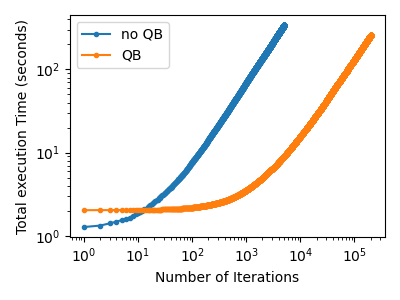

In [ ]:
# Plot execution times vs number of iterations
plt.figure(figsize=(4,3))
# by accident, did two million iterations...
plt.plot(np.arange(tn.size)[1:], tn[1:] - tn[0], marker='.', label='no QB')
plt.plot(np.arange(tqb.size)[1:200000], tqb[1:200000] - tqb[0], marker='.', label='QB')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Iterations')
plt.ylabel('Total execution Time (seconds)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/TiO2_execution_time.png', dpi=300)
